### Implementing simple Chatbot Using LangGraph

In [26]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [27]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [28]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [29]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-120b")

### We Will start With Creating Nodes

In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

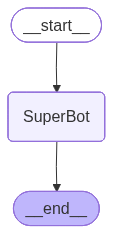

In [31]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [32]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi, I am learning LangGraph"},config)

{'messages': [HumanMessage(content='Hi, I am learning LangGraph', additional_kwargs={}, response_metadata={}, id='39959b54-a9c6-4004-bf3f-870bf2a2e00e'),
  AIMessage(content='Hello! 👋 It’s great to hear you’re diving into LangGraph. Whether you’re just getting started or looking to solve a specific problem, I’m happy to help. Here’s a quick roadmap to get you up and running, plus some tips and resources you can explore.\n\n---\n\n## 1️⃣ What Is LangGraph?\n\n**LangGraph** is a lightweight, Python‑first library for building **stateful, multi‑step workflows** (often called “graphs”) that orchestrate LLM calls, tool usage, conditional logic, and more. Think of it as a way to:\n\n| Feature | What It Gives You |\n|---------|-------------------|\n| **Nodes** | Individual steps (LLM calls, API calls, data transforms). |\n| **Edges** | Directed connections that dictate the flow based on state or output. |\n| **State** | A mutable dictionary (`state`) that persists across steps, enabling contex

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

#### Streaming The Responses With Stream Method

In [33]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,I am learning AI/ML"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello! That’s great to hear—you’re diving into a fascinating field. 🎉\n\nBelow is a quick roadmap and some resources to help you get started (or keep moving forward) with AI/ML, whether you’re a complete beginner or looking to deepen your knowledge.\n\n---\n\n## 1️⃣ Pick a Foundation\n\n| Area | Why It Matters | Starter Resources |\n|------|----------------|-------------------|\n| **Programming (Python)** | Most ML libraries are Python‑based. | • *Automate the Boring Stuff with Python* (free online)  <br>• Codecademy/FreeCodeCamp Python tracks |\n| **Linear Algebra & Calculus** | Core for understanding models, gradients, etc. | • 3Blue1Brown “Essence of Linear Algebra” (YouTube) <br>• Khan Academy – Linear Algebra & Multivariable Calculus |\n| **Probability & Statistics** | Data modeling, inference, evaluation metrics. | • *Statistical Thinking for Data Science* (Coursera) <br>• “Think Stats” by Allen B. Downey (free PDF) |\n| **Data Wrangl

In [ ]:
for chunk in graph_builder.stream({'messages':"I also learning Maths"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,I am learning AI/ML', additional_kwargs={}, response_metadata={}, id='1a466f49-416d-45f4-b56b-ab265d7c8f14'), AIMessage(content='Hello! That’s great to hear—you’re diving into a fascinating field. 🎉\n\nBelow is a quick roadmap and some resources to help you get started (or keep moving forward) with AI/ML, whether you’re a complete beginner or looking to deepen your knowledge.\n\n---\n\n## 1️⃣ Pick a Foundation\n\n| Area | Why It Matters | Starter Resources |\n|------|----------------|-------------------|\n| **Programming (Python)** | Most ML libraries are Python‑based. | • *Automate the Boring Stuff with Python* (free online)  <br>• Codecademy/FreeCodeCamp Python tracks |\n| **Linear Algebra & Calculus** | Core for understanding models, gradients, etc. | • 3Blue1Brown “Essence of Linear Algebra” (YouTube) <br>• Khan Academy – Linear Algebra & Multivariable Calculus |\n| **Probability & Statistics** | Data modeling, inference, evaluation metrics. |